**Imports**

In [19]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange

# Computing the two-point correlation function

**Task 5**

In [20]:
# Reading in the data and subsequentially cutting out a redshift range and diving between red and blue galaxies according to color.
data = pandas.read_csv('sdss_cutout.csv')
z = data['Z'].values
z_mask = (z > 0.08) & (z < 0.12)
data = data[z_mask].reset_index(drop=True)

u_mag = data['phot_u'].values
r_mag = data['phot_r'].values
color = u_mag - r_mag

red_gal = data[color > 2.3].reset_index(drop=True)
blue_gal = data[color <= 2.3].reset_index(drop=True)

# Reading out the RA and DEC values from the two populations.
red_gal_ra = red_gal['RA'].values
red_gal_dec = red_gal['DEC'].values

blue_gal_ra = blue_gal['RA'].values
blue_gal_dec = blue_gal['DEC'].values

In [21]:
# Since the red and blue samples have different sized we need to create our random samples with matching sizes.
red_len = len(red_gal)
blue_len = len(blue_gal)

# According to the NumPy documentation, this is the recommended way to create a sample from a uniform distribution.
rand = np.random.default_rng()

red_ra_rand = rand.uniform(130, 230, red_len)
red_dec_rand = rand.uniform(5, 65, red_len)

blue_ra_rand = rand.uniform(130, 230, blue_len)
blue_dec_rand = rand.uniform(5, 65, blue_len)

omega_bins = np.geomspace(0.003, 0.3, 11)

In [22]:
# To later use the formula for ω we need to convert our coordinates into spherical ones.
def ra_dec_to_spherical(ra, dec):
    """Convert RA/DEC angles from degrees to spherical coordinates.

    Parameters
    ----------
    ra : array_like
        Right ascension values in degrees.
    dec : array_like
        Declination values in degrees.

    Returns
    -------
    phi : ndarray
        Azimuthal spherical angle in radians.
    theta : ndarray
        Polar spherical angle in radians.
    """
    phi = np.pi * (ra/180)
    theta = np.pi/2 - np.pi * (dec/180)
    return phi, theta

In [23]:
# Conversion

red_phi, red_theta = ra_dec_to_spherical(red_gal_ra, red_gal_dec)
blue_phi, blue_theta = ra_dec_to_spherical(blue_gal_ra, blue_gal_dec)

red_phi_rand, red_theta_rand = ra_dec_to_spherical(red_ra_rand, red_dec_rand)
blue_phi_rand, blue_theta_rand = ra_dec_to_spherical(blue_ra_rand, blue_dec_rand)

In [24]:
# The main function to calculate the two point correlation function. We use it to count how many galaxy pairs fall inside each of the angular separation bins we defined according to the exercise sheet earlier.
@njit(parallel=True)
def count_pairs(delta1, delta2, alpha1, alpha2, edges, auto=False):
    """Count object pairs in angular separation bins.

    Parameters
    ----------
    delta1 : array_like
        First set of declination angles (theta) in radians.
    delta2 : array_like
        Second set of declination angles (theta) in radians.
    alpha1 : array_like
        First set of right ascension angles (phi) in radians.
    alpha2 : array_like
        Second set of right ascension angles (phi) in radians.
    edges : array_like
        Bin edges for angular separations (omega), in radians.
    auto : bool, optional
        If True, compute auto-correlation (i<j only) within one sample.
        If False, compute cross-correlation (all pairs).

    Returns
    -------
    counts : ndarray
        Pair counts in each angular separation bin.
    """
    bin_num = len(edges) - 1
    counts = np.zeros(bin_num, dtype=np.int64)

    for i in prange(len(alpha1)):
        cos_a = np.cos(alpha1[i])
        sin_a = np.sin(alpha1[i])
        delta = delta1[i]

        j_start = i + 1 if auto else 0

        for j in range(j_start, len(alpha2)):
            cos_omega = (cos_a * np.cos(alpha2[j]) + np.cos(delta - delta2[j]) * sin_a * np.sin(alpha2[j]))

            # Without the clamp we get quite a lot of NaNs in our results. Possibly due to floating point errors.
            if cos_omega > 1.0:
                cos_omega = 1.0
            elif cos_omega < -1.0:
                cos_omega = -1.0

            omega = np.arccos(cos_omega)

            for k in range(bin_num):
                if edges[k] <= omega < edges[k + 1]:
                    counts[k] += 1
                    break
    return counts

In [25]:
red_DD = count_pairs(red_phi, red_phi, red_theta, red_theta, omega_bins, auto=True)
red_RR = count_pairs(red_phi_rand, red_phi_rand, red_theta_rand, red_theta_rand, omega_bins, auto=True)
red_DR = count_pairs(red_phi, red_phi_rand, red_theta, red_theta_rand, omega_bins, auto=False)

In [26]:
blue_DD = count_pairs(blue_phi, blue_phi, blue_theta, blue_theta, omega_bins, auto=True)
blue_RR = count_pairs(blue_phi_rand, blue_phi_rand, blue_theta_rand, blue_theta_rand, omega_bins, auto=True)
blue_DR = count_pairs(blue_phi, blue_phi_rand, blue_theta, blue_theta_rand, omega_bins, auto=False)

In [27]:
print(red_DD)
print(red_RR)
print(red_DR)

[    99951    216036    481194   1100804   2558059   5930933  13534370
  30175048  65768520 131865799]
[    57831    145381    365100    908804   2245447   5538228  13457319
  31977076  72688945 153590227]
[   108188    269212    672845   1673369   4152164  10224490  24869519
  59107277 135219029 291478704]


In [28]:
print(blue_DD)
print(blue_RR)
print(blue_DR)

[   19099    44921   106507   255866   605715  1437222  3385263  7773881
 17294056 35319614]
[   14768    36591    91712   227506   566515  1394563  3396291  8126187
 18510493 39585986]
[   27246    67728   169037   424337  1053725  2611170  6384462 15334754
 35009791 75491150]


In [29]:
def landy_szalay(DD, RR, DR, num):
    """Compute the Landy-Szalay estimator for the two-point correlation function.

    Parameters
    ----------
    DD : array_like
        Data-Data pair counts per bin.
    RR : array_like
        Random-Random pair counts per bin.
    DR : array_like
        Data-Random pair counts per bin.
    num : int
        Number of data objects in the sample.

    Returns
    -------
    xi : ndarray
        Estimated correlation function values per bin.
    """
    return 1 + DD/RR - (num -1)/num * DR/RR

In [30]:
red_xi = landy_szalay(red_DD, red_RR, red_DR, red_len)
print(red_xi)

blue_xi = landy_szalay(blue_DD, blue_RR, blue_DR, blue_len)
print(blue_xi)

[ 0.85759858  0.63426059  0.47510297  0.37001002  0.2901028   0.22477218
  0.15772681  0.09525016  0.04458264 -0.03918135]
[ 0.44839481  0.37676543  0.31825225  0.2595489   0.20924353  0.15825799
  0.11698103  0.06962891  0.04299764 -0.01472924]


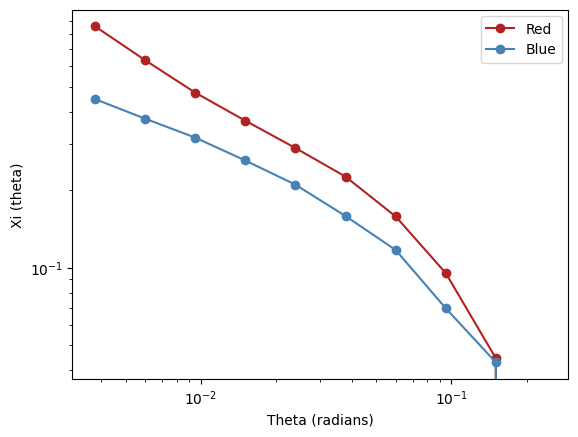

In [31]:
# We need to compute the geometric mean first. We can't use the arithmic mean since our bins are log spaced.
bin_midpoints = np.sqrt(omega_bins[:-1] * omega_bins[1:])
#degree_points = np.degrees(bin_midpoints)
plt.loglog(bin_midpoints, red_xi, 'o-', c='firebrick', label='Red')
plt.loglog(bin_midpoints, blue_xi, 'o-', c='steelblue', label='Blue')
plt.xlabel('Theta (radians)')
plt.ylabel('Xi (theta)')
plt.legend()
plt.show()

**Task 6**

In [32]:
jack_knife_regions = 6
# We only slice the data in the RA direction to save on computation time.
ra_edges = np.linspace(130, 230, jack_knife_regions + 1)

red_region = np.digitize(red_gal_ra, ra_edges[1:-1])
red_region_rand = np.digitize(red_ra_rand, ra_edges[1:-1])

blue_region = np.digitize(blue_gal_ra, ra_edges[1:-1])
blue_region_rand = np.digitize(blue_ra_rand, ra_edges[1:-1])

red_xi_samples = []
blue_xi_samples = []

In [33]:
def jackknife_xi(phi, theta, phi_rand, theta_rand, region, region_rand, omega_bins, n_regions):
    """Compute jackknife estimates of xi from data and random catalogs.

    Parameters
    ----------
    phi, theta : ndarray
        Data spherical angles (phi, theta) in radians.
    phi_rand, theta_rand : ndarray
        Random spherical angles (phi, theta) in radians.
    region, region_rand : ndarray
        Region labels for data and random points.
    omega_bins : ndarray
        Angular bin edges for pair counting.
    n_regions : int
        Number of jackknife regions.

    Returns
    -------
    xi_samples : ndarray
        Jackknife sample xi estimates for each left-out region.
    """
    xi_samples = []

    for k in range(n_regions):
        mask = region != k
        mask_rand = region_rand != k

        DD_k = count_pairs(phi[mask], phi[mask], theta[mask], theta[mask], omega_bins, auto=True)
        RR_k = count_pairs(phi_rand[mask_rand], phi_rand[mask_rand], theta_rand[mask_rand], theta_rand[mask_rand], omega_bins, auto=True)
        DR_k = count_pairs(phi[mask], phi_rand[mask_rand], theta[mask], theta_rand[mask_rand], omega_bins, auto=False)

        xi_k = landy_szalay(DD_k, RR_k, DR_k, np.sum(mask))
        xi_samples.append(xi_k)

    return np.array(xi_samples)

red_xi_all = jackknife_xi(red_phi, red_theta, red_phi_rand, red_theta_rand, red_region, red_region_rand, omega_bins, jack_knife_regions)
blue_xi_all = jackknife_xi(blue_phi, blue_theta, blue_phi_rand, blue_theta_rand, blue_region, blue_region_rand, omega_bins, jack_knife_regions)

In [34]:
print(red_xi_all)
print(blue_xi_all)

red_xi_mean = np.mean(red_xi_all, axis=0)
red_xi_std = np.std(red_xi_all, axis=0)

blue_xi_mean = np.mean(blue_xi_all, axis=0)
blue_xi_std = np.std(blue_xi_all, axis=0)

# From the equation in the lecture.
red_xi_var = ((jack_knife_regions - 1) / jack_knife_regions) * np.sum((red_xi_all - red_xi_mean)**2, axis=0)
red_xi_err = np.sqrt(red_xi_var)

blue_xi_var = ((jack_knife_regions - 1) / jack_knife_regions) * np.sum((blue_xi_all - blue_xi_mean)**2, axis=0)
blue_xi_err = np.sqrt(blue_xi_var)

print("Red xi error:", red_xi_err)
print("Blue xi error:", blue_xi_err)

[[ 0.87310874  0.64284822  0.47533752  0.36883265  0.28929726  0.22430405
   0.14970321  0.07223093  0.05866515 -0.00446941]
 [ 0.87438871  0.64572402  0.48482319  0.37589927  0.29366388  0.2258562
   0.16296765  0.10507131  0.06557425  0.02354043]
 [ 0.83461621  0.61411188  0.46626841  0.36273324  0.28514801  0.21900604
   0.15947893  0.10107433  0.06216547  0.00608309]
 [ 0.90523367  0.67869427  0.51370865  0.40906002  0.3233853   0.25419036
   0.18145442  0.11143944  0.05811432 -0.02296452]
 [ 0.8948208   0.65618926  0.49081784  0.38745358  0.30538984  0.24039531
   0.16932519  0.10049181  0.05909471 -0.00698942]
 [ 0.77014606  0.57137587  0.42483393  0.32491507  0.25189404  0.19382496
   0.13085367  0.07046607  0.05871898  0.01801165]]
[[ 0.45628321  0.38706725  0.3313065   0.26410295  0.21463066  0.16448364
   0.12893277  0.09787121  0.05699208  0.01308232]
 [ 0.44481877  0.37403269  0.31820326  0.26066992  0.20540474  0.15413877
   0.10976074  0.05598155  0.02038645 -0.042547  ]


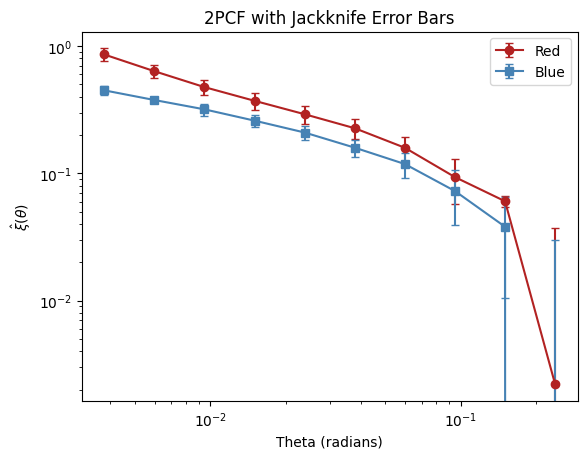

In [35]:
fig, ax = plt.subplots()

ax.errorbar(bin_midpoints, red_xi_mean, yerr=red_xi_err, fmt='o-', c='firebrick', capsize=3, label='Red')
ax.errorbar(bin_midpoints, blue_xi_mean, yerr=blue_xi_err, fmt='s-', c='steelblue', capsize=3, label='Blue')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Theta (radians)')
ax.set_ylabel(r'$\hat{\xi}(\theta)$')
ax.set_title('2PCF with Jackknife Error Bars')
ax.legend()
plt.show()